In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.colors import ListedColormap
import matplotlib.lines as mlines
from joypy import joyplot
import matplotlib.patches as patches
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

In [36]:
# Load data
df_IR = pd.read_csv(
    r"C:/Users/emill/Documents/GitHub/Coupe_Expansion/emillys_code/syll_comparison_coupe_esidaine.csv",
    encoding="utf-8",
    sep=","
)

df_SR = pd.read_csv(
    "C:/Users/emill/Documents/GitHub/Coupe_Expansion/AutomaticSylDetect.csv",
    encoding="utf-8",
    sep="\t"
)

# Clean column names
df_IR.columns = df_IR.columns.str.strip()
df_SR.columns = df_SR.columns.str.strip()

# Add SR to IR dataframe
df_IR["SR"] = df_SR["speechrate"].values

# Choose IR type
IR_type = "IR_unigram_esidaine"

# Subset columns
df = df_IR[["Language", "Text", "Speaker", IR_type , "SR"]]

# Filter only the selected languages
languages = ["FRA", "JPN", "CMN", "VIE", "YUE", "ENG", "DEU"]
df = df[df["Language"].isin(languages)]

# Map language families
df["Family"] = df["Language"].map({
    "FRA": "Indo-European",
    "JPN": "Japanese",
    "CMN": "Sino-Tibetan",
    "VIE": "Austroasiatic",
    "YUE": "Sino-Tibetan",
    "ENG": "Indo-European",
    "DEU": "Indo-European"
})

# Melt for plotting
df_long = pd.melt(df, 
                  id_vars=["Language", "Text", "Speaker", "Family"],
                  value_vars=["SR", IR_type],
                  var_name="variable", 
                  value_name="value")

# Optional: add alpha column (e.g., for plotting transparency)
df_long["alpha"] = 0.1

print(df_long.head(10))

# Preview
# print(df_long.head(100))


  Language Text     Speaker        Family variable     value  alpha
0      CMN   O1  CMN_F1(Hu)  Sino-Tibetan       SR  4.519774    0.1
1      CMN   O2  CMN_F1(Hu)  Sino-Tibetan       SR  5.611390    0.1
2      CMN   O3  CMN_F1(Hu)  Sino-Tibetan       SR  4.914005    0.1
3      CMN   O4  CMN_F1(Hu)  Sino-Tibetan       SR  5.105514    0.1
4      CMN   O6  CMN_F1(Hu)  Sino-Tibetan       SR  4.136029    0.1
5      CMN   O8  CMN_F1(Hu)  Sino-Tibetan       SR  4.661390    0.1
6      CMN   O9  CMN_F1(Hu)  Sino-Tibetan       SR  4.863222    0.1
7      CMN   P0  CMN_F1(Hu)  Sino-Tibetan       SR  5.197874    0.1
8      CMN   P1  CMN_F1(Hu)  Sino-Tibetan       SR  4.515599    0.1
9      CMN   P2  CMN_F1(Hu)  Sino-Tibetan       SR  5.101143    0.1


C:\Users\emill\AppData\Local\Temp\ipykernel_27424\1935350525.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_df.groupby("Language")["Family"]
c:\Users\emill\anaconda3\envs\coupe_env\Lib\site-packages\joypy\joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)
c:\Users\emill\anaconda3\envs\coupe_env\Lib\site-packages\joypy\joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,
C:\Users\emill\AppData\Local\Temp\ipykernel_27424\1935350525.py:58: Futu

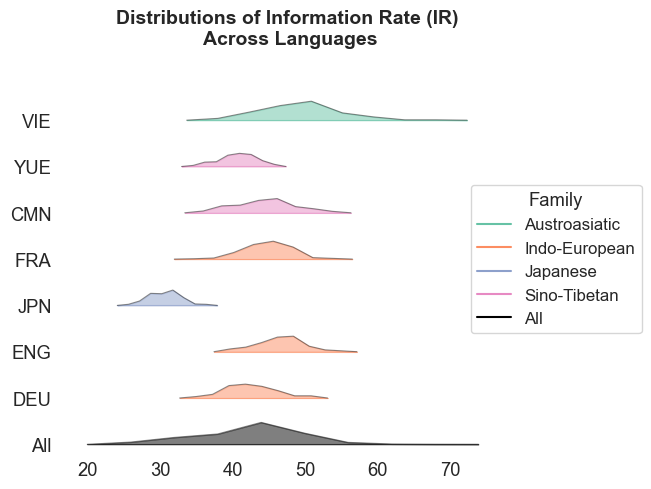

In [37]:
# ----------------- Prepare Data ----------------- #
tmp = df_long.copy()

# Compute summary statistics
tmp_summaries = tmp.groupby("variable")["value"].agg([
    "mean", "median", "std", lambda x: x.quantile(0.75) - x.quantile(0.25)
]).reset_index()
tmp_summaries.columns = ["variable", "mean", "median", "sd", "IQR"]

# Order languages by SR mean
SRs_by_language = tmp[tmp["variable"] == "SR"].groupby("Language")["value"].mean().sort_values()
ordered_languages = [lang for lang in SRs_by_language.index if lang in tmp["Language"].unique()]

# Add "All" row
all_data = tmp.copy()
all_data["Language"] = "All"
all_data["Family"] = "All"
all_data["alpha"] = 0.0
tmp = pd.concat([tmp, all_data], axis=0)

if "All" not in ordered_languages:
    ordered_languages.append("All")

tmp["Language"] = pd.Categorical(tmp["Language"], categories=ordered_languages, ordered=True)
tmp.sort_values("Language", inplace=True)

# Define color palette
families = sorted(tmp["Family"].dropna().unique())
family_list = [f for f in families if f != "All"]
color_palette = sns.color_palette("Set2", len(family_list))
palette_dict = {f: c for f, c in zip(family_list, color_palette)}
palette_dict["All"] = "black"

# ----------------- Plot ----------------- #
row_height = 0.6
num_langs = len(ordered_languages)
fig, axes = plt.subplots(1, 2, figsize=(6, num_langs * row_height), sharey=True)
variables = ["SR", "IR_unigram_esidaine"]

for i, var in enumerate(variables):
    ax = axes[i]
    sub_df = tmp[tmp["variable"] == var]

    # Draw full grid (horizontal and vertical lines to make it look like a table)
    for j in range(len(ordered_languages)):
        y = j
        ax.axhline(y=y - 0.5, color='lightgray', linestyle='-', linewidth=1, zorder=1)

    # Add vertical grid lines manually (to simulate columns)
    x_min, x_max = 25, 60
    x_grid_step = 5
    x_vals = list(range(x_min, x_max + x_grid_step, x_grid_step))
    for x in x_vals:
        ax.axvline(x=x, color='lightgray', linestyle='-', linewidth=1, zorder=1)

    # Colors per Family
    color_dict = (
        sub_df.groupby("Language")["Family"]
        .first()
        .map(palette_dict)
        .to_dict()
    )
    colors = [color_dict.get(lang, "black") for lang in ordered_languages if lang in color_dict]

    # Joyplot
    joyplot(
        data=sub_df,
        by="Language",
        column="value",
        ax=ax,
        fade=False,
        range_style='own',
        color=colors,
        linewidth=0.8,
        alpha=0.5,
        kind='normalized_counts',
        overlap=0.5
    )

    # Stats lines
    stats = tmp_summaries[tmp_summaries["variable"] == var]
    mean = stats["mean"].values[0]
    sd = stats["sd"].values[0]

    ax.axvline(mean, color='black', lw=1.2, label='Mean')
    ax.axvline(mean - sd, color='black', ls='--', lw=0.8, alpha=0.7, label='±1 SD')
    ax.axvline(mean + sd, color='black', ls='--', lw=0.8, alpha=0.7)
    if i == 0:  
        ax.legend(loc='lower left')

    ax.set_yticks(range(len(ordered_languages)))
    ax.set_yticklabels(list(reversed(ordered_languages)), fontsize=8)
    ax.set_xlim(25, 60)
    ax.set_title("Information Rate (IR)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Information Rate (bits/sec)", fontsize=12)
    ax.tick_params(axis='y', length=0)

    # Add vertical lines for each row (representing columns)
    for j in range(len(ordered_languages) + 1):
        ax.axvline(x=30 + j * 5, color='gray', linestyle='-', linewidth=1)  # Simulated vertical grid lines

# Legend
legend_handles = [
    mlines.Line2D([], [], color=palette_dict[f], label=f) for f in palette_dict
]
fig.legend(
    handles=legend_handles,
    title="Family",
    loc='center right',
    bbox_to_anchor=(1.1, 0.5)
)

fig.suptitle("Distributions of Information Rate (IR) \nAcross Languages", fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.subplots_adjust(right=0.85)
plt.savefig("Figure.tiff", dpi=600)
plt.show()

c:\Users\emill\anaconda3\envs\coupe_env\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\emill\anaconda3\envs\coupe_env\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\emill\anaconda3\envs\coupe_env\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


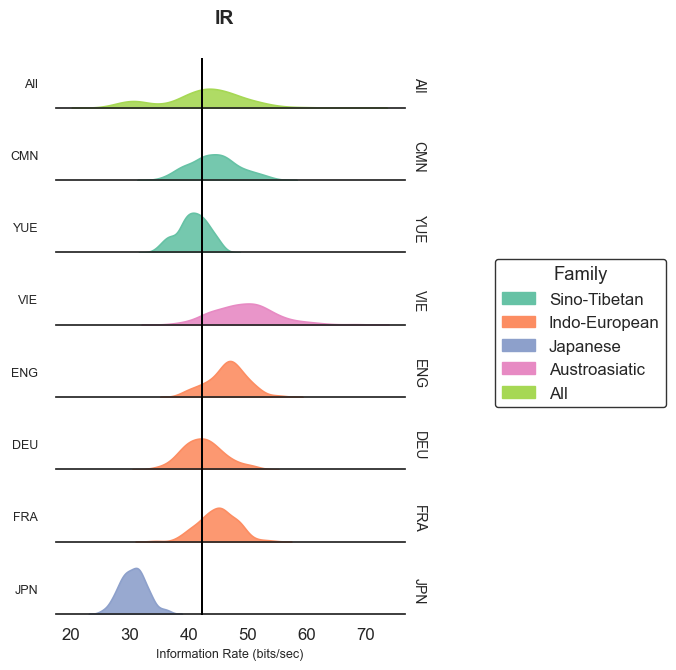

In [47]:
# === Step 1: Prepare the data ===
df_sn = df[df['Language'] != 'All']
df_sn = df_sn.melt(id_vars=['Language', 'Family'], 
                   value_vars=['IR_unigram_esidaine', 'SR'], 
                   var_name='Metric', value_name='Value')
df_sn = df_sn[df_sn['Metric'] == 'IR_unigram_esidaine'].dropna()

# Add aggregated "All" row
all_data = df_sn.copy()
all_data["Language"] = "All"
all_data["Family"] = "All"
df_sn = pd.concat([df_sn, all_data], axis=0)


ordered_languages = ["All", "CMN", "YUE", "VIE", "ENG", "DEU", "FRA", "JPN"]
df_sn['Language'] = pd.Categorical(df_sn['Language'],
                                   categories=ordered_languages,
                                   ordered=True)

# === Step 2: Setup seaborn ===
sns.set(style="white", font_scale=1.1)

# Create color palette by Family
unique_families = df_sn['Family'].dropna().unique()
palette_dict = dict(zip(unique_families, sns.color_palette("Set2", len(unique_families))))
df_sn["Color"] = df_sn["Family"].map(palette_dict)

# === Step 3: Plot ===
g = sns.FacetGrid(df_sn, row="Language", hue="Family", aspect=5, height=0.9, 
                  palette=palette_dict, margin_titles=True)

# KDE per language
g.map_dataframe(sns.kdeplot, x="Value", fill=True, alpha=0.9, linewidth=1.2, common_norm=False)

# Draw KDE boundaries and mean
def draw_mean(data, color, **kwargs):
    global_mean = df_sn[df_sn['Language'] == 'All']["Value"].mean()

    # Convert global_mean (data coordinates) to figure x-coordinate
    # Use the leftmost axis to transform the value to figure coordinates
    x_fig = g.axes[0][0].transData.transform((global_mean, 0))[0]  # in pixels
    x_fig_norm = x_fig / g.figure.bbox.width  # normalize to [0, 1] for figure

    # Add a single vertical line in figure coordinates
    g.figure.lines.append(plt.Line2D(
        [x_fig_norm, x_fig_norm], [0.11, 0.88],  # y-range (adjust as needed)
        transform=g.figure.transFigure,
        color='black', linestyle='-', linewidth=1.2
    ))

# Add custom lines
g.map_dataframe(draw_mean)

# Aesthetic tweaks
g.set_titles(row_template="{row_name}", col_template="", size=10)

# Remove vertical facet labels (the default row labels)
for ax in g.axes[:, 0]:  # Only need to do this for one column
    if hasattr(ax, 'get_ylabel'):
        ax.set_ylabel("")

for ax, label in zip(g.axes.flat, df_sn['Language'].cat.categories):
    ax.text(-0.05, 0.5, label, transform=ax.transAxes,
            fontsize= 9 , va='center', ha='right', rotation=0)

g.set(yticks=[], ylabel="")
g.set_xlabels("Information Rate (bits/sec)", size=9)
g.despine(left=True, bottom=False)
plt.subplots_adjust(hspace=0.5)
plt.suptitle("IR", fontsize=14, fontweight='bold', y=0.95)

# Create a square-based legend with border
legend_handles = [
    mpatches.Patch(color=palette_dict[f], label=f) for f in palette_dict
]
legend = g.fig.legend(
    handles=legend_handles,
    title="Family",
    loc='center right',
    bbox_to_anchor=(1.5, 0.5),
    frameon=True,  # Adds a border around the legend
    edgecolor='black'
)

plt.show()